In [112]:
import pandas as pd 
import numpy as np

### loading data

In [113]:
df=pd.read_csv("train_transaction.csv")

In [18]:
Y=df["isFraud"]
df=df.drop(columns=["isFraud"])

### Data preprocessing

In [114]:
# removing v features which have huge null values
cols_to_drop = []

for col in ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V127', 'V128', 'V129', 'V130', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243', 'V244', 'V245', 'V246', 'V247', 'V248', 'V249', 'V250', 'V251', 'V252', 'V253', 'V254', 'V255', 'V256', 'V257', 'V258', 'V259', 'V260', 'V261', 'V262', 'V263', 'V264', 'V265', 'V266', 'V267', 'V268', 'V269', 'V270', 'V271', 'V272', 'V273', 'V274', 'V275', 'V276', 'V277', 'V278', 'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287', 'V288', 'V289', 'V290', 'V291', 'V292', 'V293', 'V294', 'V295', 'V296', 'V297', 'V298', 'V299', 'V300', 'V301', 'V302', 'V303', 'V304', 'V305', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V316', 'V317', 'V318', 'V319', 'V320', 'V321', 'V322', 'V323', 'V324', 'V325', 'V326', 'V327', 'V328', 'V329', 'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338', 'V339']:
   if df[col].isnull().mean() > 0.5 :
        cols_to_drop.append(col)

df = df.drop(columns=cols_to_drop)

#creating 3-new features from timespaces
df["Days since last transition"]=df[['D1', 'D2']].mean(axis=1)
df["Days since last transition"] = df["Days since last transition"].fillna(
    df["Days since last transition"].mean()
)
df=df.drop(columns=['D1','D2'])
cols = ['D8', 'D10', 'D15']

df['last_change'] = df[cols].max(axis=1).fillna(0)
df=df.drop(columns=['D8','D10','D15',])
colms=['D5','D6','D7','D11','D12','D13']
df["unknows"]=df[colms].mean(axis=1)
df=df.drop(columns=['D5','D6','D7','D11','D12','D13'])
df["unknows"] = df["unknows"].fillna(
    df["unknows"].mean()
)
print(df['unknows'].isnull().sum())
 
# removing other features which have high value null values
new_col=[]
for col in df.columns:
   if df[col].isnull().mean() > 0.6:
        new_col.append(col)
df = df.drop(columns=new_col)


#feature engieerning
df['P_emaildomain_flag'] = df['P_emaildomain'].str.contains('.com', na=False).astype(int)

#removing V features which are highly coorelated
import numpy as np


v_cols = [col for col in df.columns if col.startswith('V')]


corr_matrix = df[v_cols].corr().abs()


upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)


threshold = 0.85

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]


df = df.drop(columns=to_drop, errors='ignore')

print(f"Dropped {len(to_drop)} columns")
#removing v which have low variance
from sklearn.feature_selection import VarianceThreshold

v_cols = [col for col in df.columns if col.startswith('V')]

selector = VarianceThreshold(threshold=0.1)
selector.fit(df[v_cols])

low_var_v = [col for col, keep in 
             zip(v_cols, selector.get_support()) if not keep]

df.drop(columns=low_var_v, inplace=True)
print(f"Dropped {len(low_var_v)} low variance V features")

#dropping used columns
df=df.drop(columns=["card3","card5","addr2"])
df=df.drop(columns=["P_emaildomain","TransactionID"])

#encoding and filling null values

df_encoded = pd.get_dummies(df, columns=['ProductCD', 'card4', 'card6'], drop_first=False)
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


0
Dropped 103 columns
Dropped 36 low variance V features


### Scalling and pca


Number of components selected: 39
Total variance retained: 0.9421951475278592


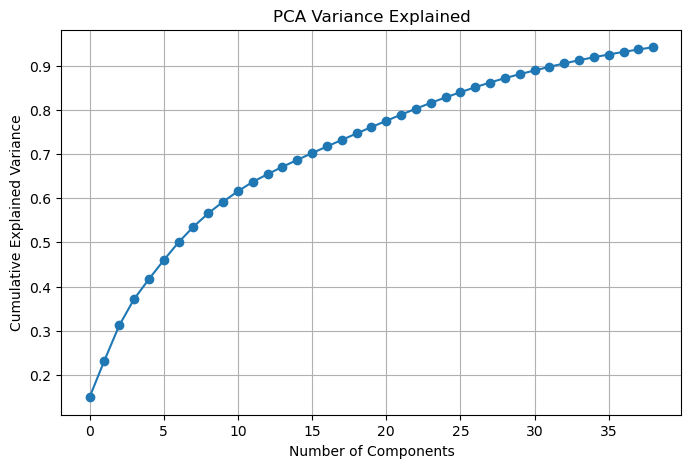

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.402776 -0.684267 -0.486150  1.436847 -1.021975 -1.295786  0.387121   
1 -0.234181  0.453458 -1.385553 -0.424878  1.644132 -0.662015 -0.661832   
2 -0.392870 -0.739516 -0.690278  1.547790  0.016469  0.410033  0.916050   
3 -0.316262 -1.312319  2.624051  0.656290  0.591425  0.749777  1.235496   
4 -0.304621  0.297039 -1.017418  0.397608  0.321852 -0.599831  0.178289   

        PC8       PC9      PC10  ...      PC30      PC31      PC32      PC33  \
0 -0.165896  0.023064 -0.494824  ... -0.905591  0.173348 -0.967850  0.377804   
1 -0.259275  0.707532  0.102979  ... -0.455858 -0.138162 -0.010195 -0.677245   
2 -0.034404 -0.969720 -0.058484  ... -0.458338 -0.968064  1.407279 -1.139007   
3 -1.143754 -0.256661 -2.924560  ...  0.287850 -0.033993 -0.152094 -0.236386   
4 -0.073191  0.203933 -0.120076  ...  0.303619 -0.121454  0.116590 -0.446015   

       PC34      PC35      PC36      PC37      PC38      PC39  
0  0

In [116]:
# ================================
# 1. Import libraries
# ================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# ================================
# 2. Select numeric columns
# ================================
num_cols = df.select_dtypes(include=['number']).columns
X = df[num_cols]


# ================================
# 3. Handle missing values (mean)
# ================================
X = X.fillna(X.mean())


# ================================
# 4. Scaling (Standardization)
# ================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ================================
# 5. Apply PCA (retain 95% variance)
# ================================
pca = PCA(n_components=0.94)
X_pca = pca.fit_transform(X_scaled)


# ================================
# 6. Convert to DataFrame
# ================================
X_pca_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i}' for i in range(1, X_pca.shape[1] + 1)]
)


# ================================
# 7. Explained variance info
# ================================
print("Number of components selected:", pca.n_components_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())


# ================================
# 8. Plot cumulative variance
# ================================
plt.figure(figsize=(8,5))
plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.grid()
plt.show()


# ================================
# 9. Final dataset
# ================================
print(X_pca_df.head())

### K-MEANS CLUSTERING

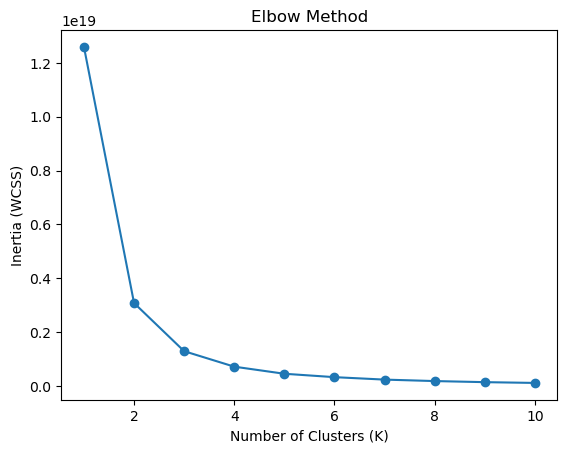

In [117]:
# finding best value of k using elbow method
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

K_range = range(1, 11)  # try K from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)   # X = your feature matrix
    inertia.append(kmeans.inertia_)

# Plot
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.show()

In [127]:
#using that k to tarin the model
kmeans = KMeans(n_clusters=2, random_state=42)
clusters= kmeans.fit_predict(X)


mapped = np.zeros_like(clusters)

for c in np.unique(clusters):
    mask = clusters == c
    mapped[mask] = Y[mask].mode()[0] if hasattr(Y, "mode") else np.bincount(Y[mask]).argmax()

In [128]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print("accuracy :" ,accuracy_score(Y,clusters))
print(classification_report(Y, clusters))

accuracy : 0.5118027567988621
              precision    recall  f1-score   support

           0       0.97      0.51      0.67    569877
           1       0.04      0.51      0.07     20663

    accuracy                           0.51    590540
   macro avg       0.50      0.51      0.37    590540
weighted avg       0.93      0.51      0.65    590540



In [129]:
# understanding distribution of classes
import numpy as np

print("Cluster counts:", np.bincount(clusters))
print("Class counts:", np.bincount(Y))

Cluster counts: [302005 288535]
Class counts: [569877  20663]


### Isolation forest

In [151]:
from sklearn.ensemble  import IsolationForest
model=IsolationForest(  
    contamination = 0.1,
    random_state=42,
    n_jobs=-1)
model.fit(X)
scores = model.decision_function(X)

threshold = np.percentile(scores, 5)  # more aggressive

anomaly_labels = (scores < threshold).astype(int)
from sklearn.metrics import accuracy_score
print("accuracy :" ,accuracy_score(Y,anomaly_labels))

accuracy : 0.9359636942459444


In [152]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(Y,anomaly_labels ))
print(classification_report(Y, anomaly_labels))

[[546537  23340]
 [ 14476   6187]]
              precision    recall  f1-score   support

           0       0.97      0.96      0.97    569877
           1       0.21      0.30      0.25     20663

    accuracy                           0.94    590540
   macro avg       0.59      0.63      0.61    590540
weighted avg       0.95      0.94      0.94    590540



### visualization

### 1)PCA Space Analysis-Actual data ,Isolation forest,Kmeans

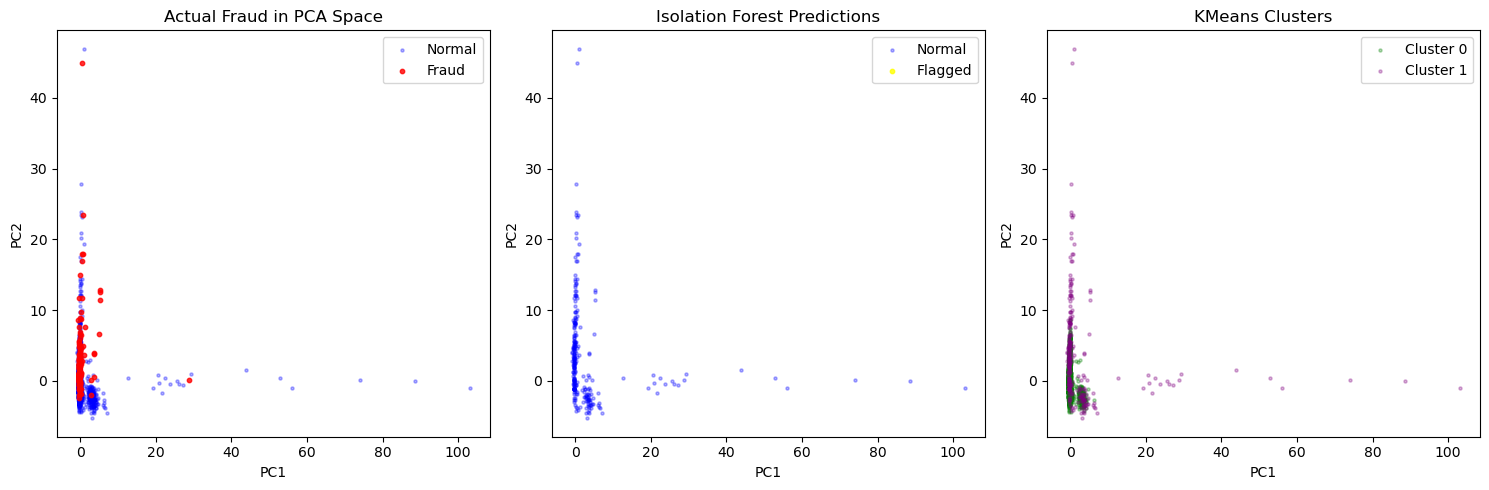

In [157]:
import matplotlib.pyplot as plt
import numpy as np

# Sample for visualization (plotting 590K points = slow)
sample_idx = np.random.choice(len(X_pca), 5000, replace=False)
X_sample = X_pca[sample_idx]
fraud_sample = df['isFraud'].values[sample_idx]
anomaly_sample = anomaly_labels[sample_idx]


plt.figure(figsize=(15, 5))

# Plot 1 — Actual Fraud in PCA space
plt.subplot(1, 3, 1)
plt.scatter(X_sample[fraud_sample==0, 0], 
            X_sample[fraud_sample==0, 1],
            c='blue', alpha=0.3, s=5, label='Normal')
plt.scatter(X_sample[fraud_sample==1, 0], 
            X_sample[fraud_sample==1, 1],
            c='red', alpha=0.8, s=10, label='Fraud')
plt.title('Actual Fraud in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

# Plot 2 — Isolation Forest Predictions
plt.subplot(1, 3, 2)
plt.scatter(X_sample[anomaly_sample==1, 0],
            X_sample[anomaly_sample==1, 1],
            c='blue', alpha=0.3, s=5, label='Normal')
plt.scatter(X_sample[anomaly_sample==-1, 0],
            X_sample[anomaly_sample==-1, 1],
            c='yellow', alpha=0.8, s=10, label='Flagged')
plt.title('Isolation Forest Predictions')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

# Plot 3 — KMeans Clusters
plt.subplot(1, 3, 3)
cluster_sample=clusters[sample_idx]
plt.scatter(X_sample[cluster_sample==0, 0],
            X_sample[cluster_sample==0, 1],
            c='green', alpha=0.3, s=5, label='Cluster 0')
plt.scatter(X_sample[cluster_sample==1, 0],
            X_sample[cluster_sample==1, 1],
            c='purple', alpha=0.3, s=5, label='Cluster 1')
plt.title('KMeans Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150)
plt.show()

### 2) Transaction Amount Distribution and days pass after last tarnstion

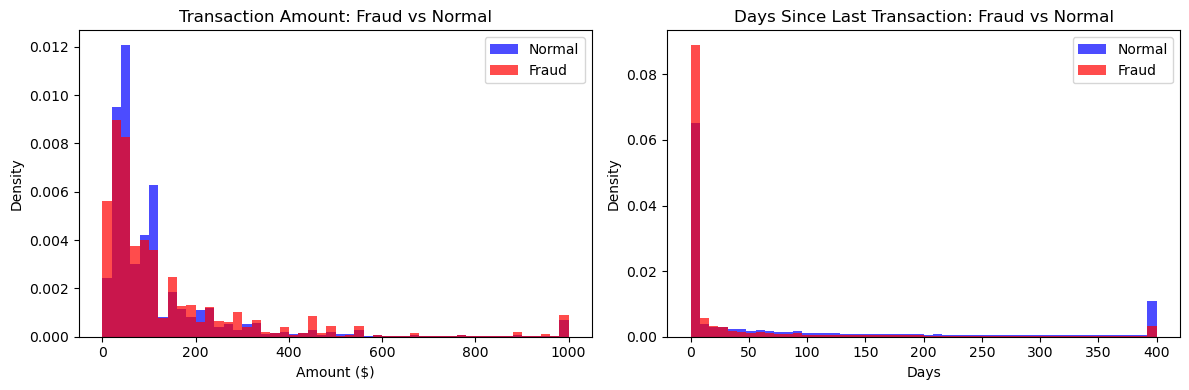

In [158]:
plt.figure(figsize=(12, 4))

# Plot 1 — Amount distribution
plt.subplot(1, 2, 1)
plt.hist(df[df['isFraud']==0]['TransactionAmt'].clip(0, 1000),
         bins=50, alpha=0.7, color='blue', label='Normal', density=True)
plt.hist(df[df['isFraud']==1]['TransactionAmt'].clip(0, 1000),
         bins=50, alpha=0.7, color='red', label='Fraud', density=True)
plt.title('Transaction Amount: Fraud vs Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Density')
plt.legend()

# Plot 2 — Days since last transaction
plt.subplot(1, 2, 2)
plt.hist(df[df['isFraud']==0]['Days since last transition'].clip(0, 400),
         bins=50, alpha=0.7, color='blue', label='Normal', density=True)
plt.hist(df[df['isFraud']==1]['Days since last transition'].clip(0, 400),
         bins=50, alpha=0.7, color='red', label='Fraud', density=True)
plt.title('Days Since Last Transaction: Fraud vs Normal')
plt.xlabel('Days')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()
plt.savefig('distribution_visualization.png', dpi=150)
plt.show()

### Comparsion 

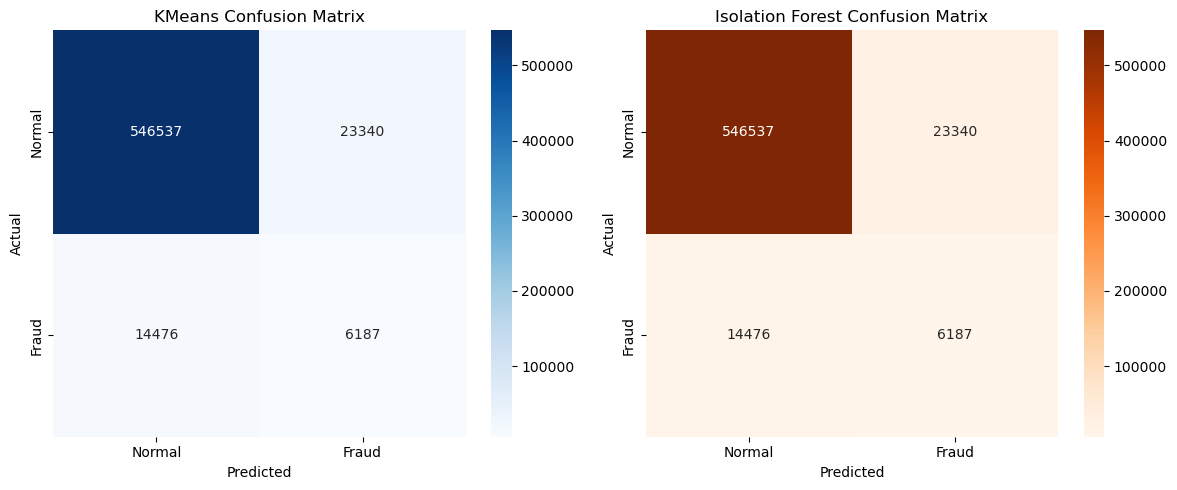

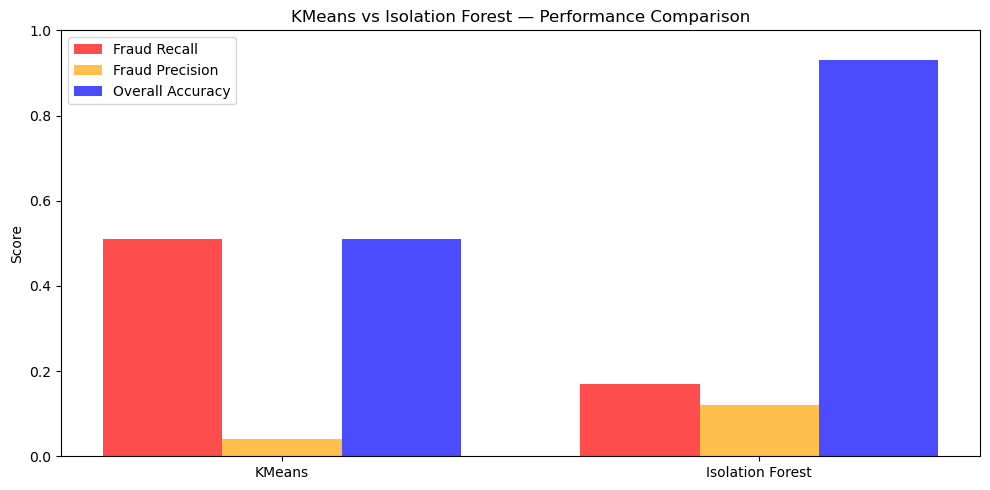

In [162]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KMeans confusion matrix

cm_km = confusion_matrix(df['isFraud'],clusters)
sns.heatmap(cm_km, annot=True, fmt='d', ax=axes[0],
            cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[0].set_title('KMeans Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Isolation Forest confusion matrix

cm_iso = confusion_matrix(df['isFraud'], anomaly_labels)
sns.heatmap(cm_iso, annot=True, fmt='d', ax=axes[1],
            cmap='Oranges',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[1].set_title('Isolation Forest Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

# Summary bar chart
models = ['KMeans', 'Isolation Forest']
fraud_recall = [0.51, 0.17]
fraud_precision = [0.04, 0.12]
accuracy = [0.51, 0.93]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, fraud_recall, width, label='Fraud Recall', color='red', alpha=0.7)
plt.bar(x, fraud_precision, width, label='Fraud Precision', color='orange', alpha=0.7)
plt.bar(x + width, accuracy, width, label='Overall Accuracy', color='blue', alpha=0.7)
plt.xticks(x, models)
plt.ylabel('Score')
plt.title('KMeans vs Isolation Forest — Performance Comparison')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150)
plt.show()